<a href="https://colab.research.google.com/github/Felipe-Tagawa/Treino-IA/blob/main/Exercicio_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício EDA - Felipe Tagawa

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd "/content/drive/MyDrive/DATASET IRIS AULA 3"

/content/drive/MyDrive/DATASET IRIS AULA 3


In [4]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

In [5]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df.rename(columns={"target":"species_id"}, inplace=True)

df["species"] = iris.target_names[df["species_id"]]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [6]:
display(df.describe())

display(df.shape)
display(df.columns)

display(df.info())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


(150, 6)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species_id', 'species'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species_id         150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


None

## Verificar balanceamento

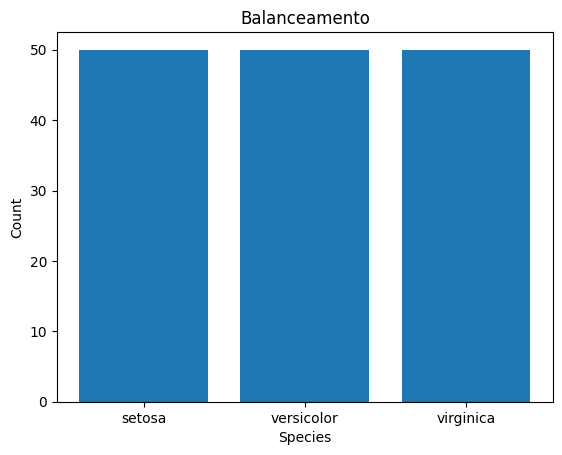

In [7]:
plt.bar(df["species"].unique(), df["species"].value_counts())
plt.title("Balanceamento")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

## Verificar valores nulos ou duplicados

In [8]:
print(df.isnull().sum())
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_id           0
species              0
dtype: int64
1
0


## Gráficos

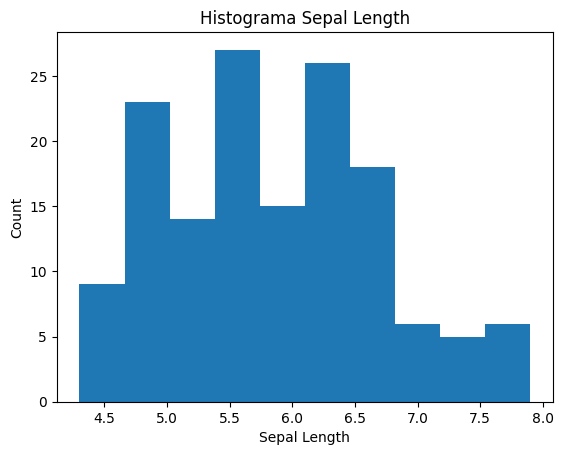

In [9]:
plt.hist(df["sepal length (cm)"])
plt.title("Histograma Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Count")
plt.show()

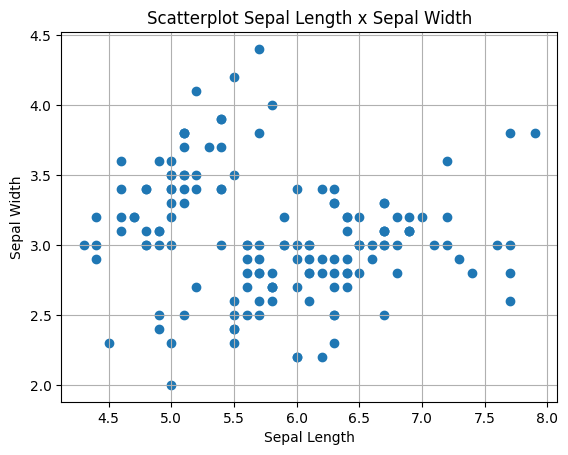

In [13]:
plt.scatter(df["sepal length (cm)"], df["sepal width (cm)"])
plt.title("Scatterplot Sepal Length x Sepal Width")
plt.grid()
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

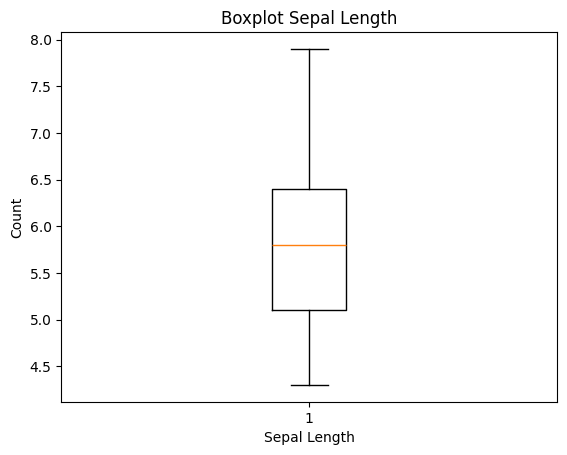

In [11]:
plt.boxplot(df["sepal length (cm)"])
plt.title("Boxplot Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Count")
plt.show()

## Variáveis Numéricas

In [12]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

df = pd.get_dummies(df, columns=cat_cols, dtype=int)

df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species_setosa,species_versicolor,species_virginica
sepal length (cm),1.000000,-0.118129,0.873738,0.820620,0.786971,-0.718879,0.079280,0.642853
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894,-0.422987,0.601821,-0.473476,-0.128997
petal length (cm),0.873738,-0.426028,1.000000,0.962772,0.949402,-0.922494,0.206123,0.720018
petal width (cm),0.820620,-0.362894,0.962772,1.000000,0.956514,-0.886988,0.122833,0.768044
species_id,0.786971,-0.422987,0.949402,0.956514,1.000000,-0.866030,0.005852,0.864556
species_setosa,-0.718879,0.601821,-0.922494,-0.886988,-0.866030,1.000000,-0.505051,-0.497468
species_versicolor,0.079280,-0.473476,0.206123,0.122833,0.005852,-0.505051,1.000000,-0.497468
species_virginica,0.642853,-0.128997,0.720018,0.768044,0.864556,-0.497468,-0.497468,1.000000


### Insights

Tratamento de Dados:

*   Não há itens faltantes;
*   Havia 1 registro duplicado e foi devidamente removido;
*   Uma coluna é categórica e todas as outras são numéricas (Valores flutuantes);
*   O dataset é balanceado, facilitando a análise final;
*   A relação entre quantidade de amostras e comprimento da 'Sepal' segue o modelo normalizado em média.



# Dataset 2 - Heart Failure

In [15]:
!pip install kagglehub

In [16]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "heart.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "fedesoriano/heart-failure-prediction",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_747/4287840449.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
First 5 records:    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


## Análises Iniciais

In [17]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [20]:
display(df.shape)
display(df.columns.tolist())
display(df.dtypes)

display(df.info())

(918, 12)

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'HeartDisease']

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


None

## Verificar Balanceamento

In [26]:
TARGET = 'HeartDisease'

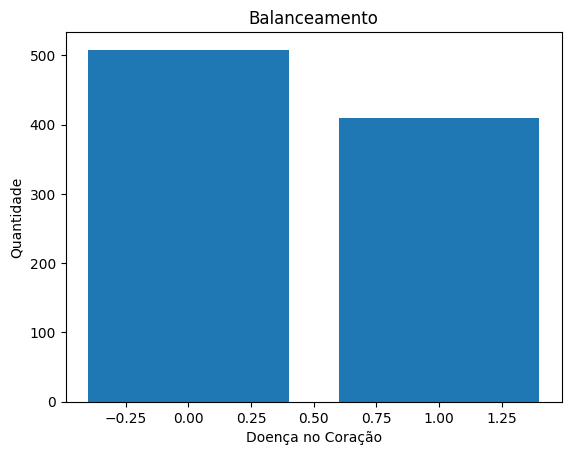

In [28]:
plt.bar(df["HeartDisease"].unique(), df["HeartDisease"].value_counts())
plt.title("Balanceamento")
plt.xlabel("Doença no Coração")
plt.ylabel("Quantidade")
plt.show()

Usando a target como base, podemos notar que o dataset não é balanceado, mas faz sentido em casos médicos.

## Verificando valores do dataset

In [21]:
print(df.isnull().sum())
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
0
0


O dataset não possui valores nulos nem duplicados.

# Gráficos

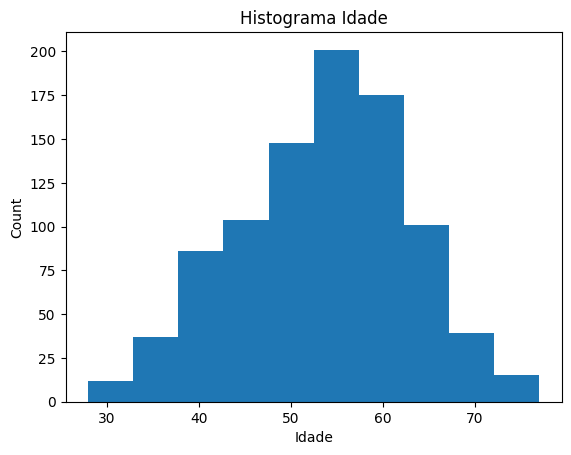

In [29]:
plt.hist(df["Age"])
plt.title("Histograma Idade")
plt.xlabel("Idade")
plt.ylabel("Count")
plt.show()

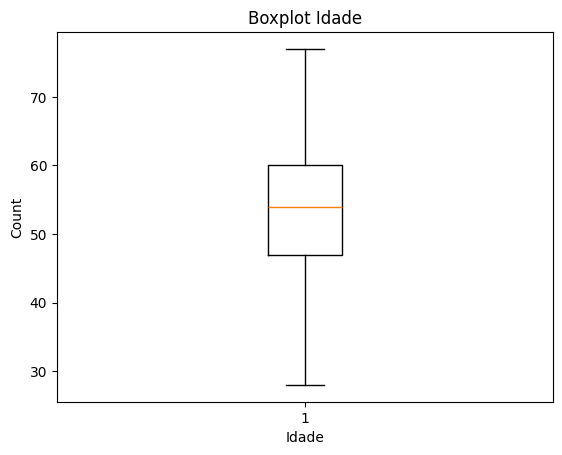

In [30]:
plt.boxplot(df["Age"])
plt.title("Boxplot Idade")
plt.xlabel("Idade")
plt.ylabel("Count")
plt.show()

Text(0, 0.5, 'Age')

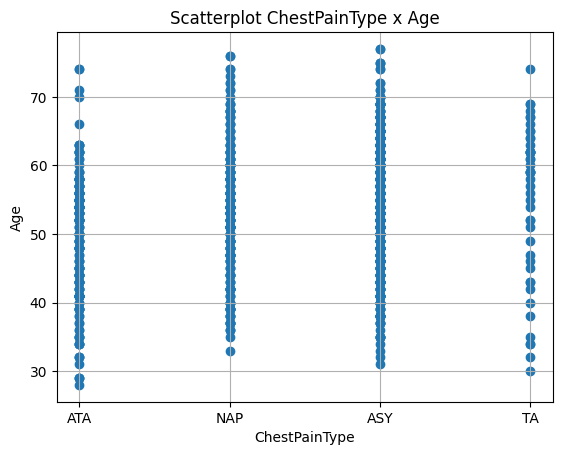

In [32]:
plt.scatter(df["ChestPainType"], df["Age"])
plt.title("Scatterplot ChestPainType x Age")
plt.grid()
plt.xlabel("ChestPainType")
plt.ylabel("Age")